# Example:

## Ship Lines Optimization in Southeastern Asia

In this file, we will demonstrate how to optimize the shipline network step by step using the `cma` package.

First of all, import the `cma` package. 

In [1]:
import cma

We focus on a specific region: the maritime network within Southeastern Asia. 

This region fully encompasses the following 10 ASEAN countries, some ports in southern China, Taiwan and parts of South Asia, basically covers the main ports along the coast of the South China Sea.

In [3]:
southeastern_asia = [
	'Vietnam', 'Myanmar', 'Laos', 'Thailand', 'Cambodia',
	'Indonesia', 'Philippines', 'Malaysia', 'Singapore',
	'Brunei', 'Timor-Leste'
]

### 1. Ports and Demands

Southeast Asia, as a key region for global maritime trade, is home to many ports.

Let's display the distribution of all thees ports in this region.

In Total  43  ports are plotted


/opt/anaconda3/envs/nuscma/lib/python3.11/site-packages/shapely/predicates.py:878: RuntimeWarning: invalid value encountered in intersects
  return lib.intersects(a, b, **kwargs)


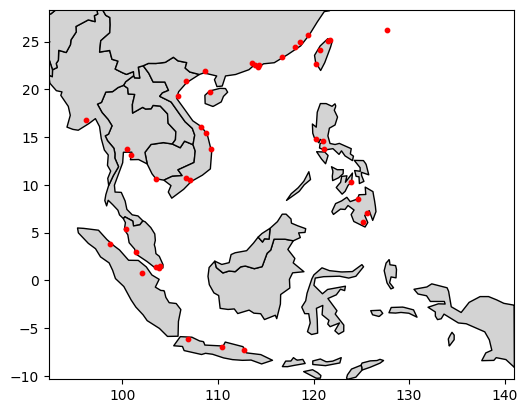

In [4]:
# load vessels data
vesselpool = cma.read_vessel_class_data()

# load ports data
_, portpool = cma.read_port_data()

# filtered by `southeastern_asia` region
_, ax, portpool_2 = portpool.plot(southeastern_asia)

From the image above, we have a visualization of the distribution of ports in the Southeast Asia region: 
There are 41 ports considered, as the program tells us. 

Next, let's examine the freight demand among these ports. 
In fact, not all port pairs have freight demand between them. 

(Please note that in this example, we are focusing solely on the demand within the region and excluding the demand between the region and external areas.)

In total 40 have freight demand


/opt/anaconda3/envs/nuscma/lib/python3.11/site-packages/shapely/predicates.py:878: RuntimeWarning: invalid value encountered in intersects
  return lib.intersects(a, b, **kwargs)


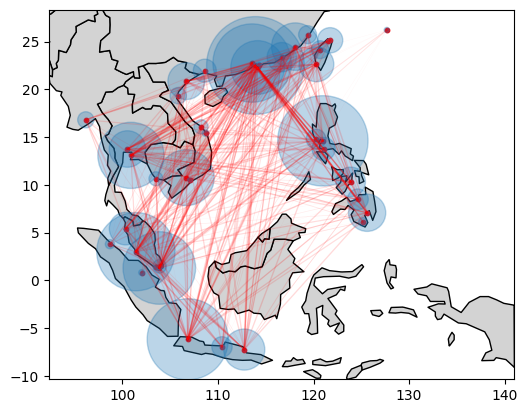

In [5]:
# load weekly demand data
_, weekly_demand = cma.read_demand_data(portpool_2)

# load mutual sailing distance data
dist_mat = cma.read_sailing_distance_data(portpool_2)

# create a new pool of ports with richer information
portgraph = cma.PortGraph(portpool_2, dist_mat, weekly_demand)
num_ports = portgraph.get_number_of_ports()
print(f'In total {num_ports} have freight demand')

# plot the demands between ports
_, ax, _ = portgraph.plot(southeastern_asia)

In the above image, there are a total of 40 ports are involved in cargo transportation, which is only slightly different from the total number of ports.

The traffic level at each port (total inbound and outbound cargo) is represented by light blue circles. The larger the circle, the greater the volume of cargo handled at the port. 

The red lines represent the demand between ports, with the color intensity and line thickness indicating the volume of cargo.

All data related to demand has been inherited into the `PortGraph` class.
Besides the demand data, this class also contains the nautical distance between any two ports. We have defined methods such as `get_distance` and `get_demand` in the class.

> **Note:**
>
> It is worth noting that the nautical distance is not available for every pair of ports. There are missing data. 
>
> For those edges with missing distance, we currently set infinity as a placeholder to indicate that the sea route is unavailable. 
>
> There are 126 such missing values in `dist_mat` in total. If these edges appear in a route, it means the route is not feasible.

In [6]:
# statistics
pairs = portgraph.get_pairs_missing_distance()
len(pairs)

126

### 2. Network Optimization

Now, let's move on to the maritime route optimization section.

First, we will read the existing routes from the data. It is important to emphasize that Our current model only considers the most standard routes: 

1) Ships cannot visit the same port consecutively, and 

2) The same directed segment (of two ports) cannot appear twice in the route 

The second restriction is mainly to facilitate path searching in the cargo allocation problem and decrease the size of action space of line adjustment. 

In [7]:
# load current lines
current_lines, _ = cma.read_current_line_data(portgraph)
print(f'Successfully load {len(current_lines)} lines')

Successfully load 10 lines


In [8]:
# create a graph network
servicegraph = cma.ServiceGraph(current_lines)
servicegraph

CP2CNC -- [CNSHK, HKHKG, CNNSA, PHMNL, PHBTG, PHDVO]
CP3CNC -- [TWKHH, CNSHK, HKHKG, PHSFS, PHCEB, PHCGY]
HHX3CNC -- [CNNSA, CNSHK, HKHKG, VNHPH]
JSSCNC -- [SGSIN, MYPKG, IDJKT, IDSUB]
LCXPCNC -- [THLCH, SGSIN]
RBHCNC -- [THBKK, THLCH, VNHPH, CNNSA, CNSHK, THLCH]
RMNCNC -- [PHSFS, PHMNL, SGSIN]
SGSCNC -- [SGSIN, VNSGN]
SPXCNC -- [SGSIN, PHDVO, PHGES]
TIXCNC -- [THLCH, IDJKT]

#### 2.1. A Glance of Current Lines

Alright, we have successfully read the 10 existing maritime routes. 

Their paths are plotted as follows:

/opt/anaconda3/envs/nuscma/lib/python3.11/site-packages/shapely/predicates.py:878: RuntimeWarning: invalid value encountered in intersects
  return lib.intersects(a, b, **kwargs)
/opt/anaconda3/envs/nuscma/lib/python3.11/site-packages/shapely/predicates.py:878: RuntimeWarning: invalid value encountered in intersects
  return lib.intersects(a, b, **kwargs)



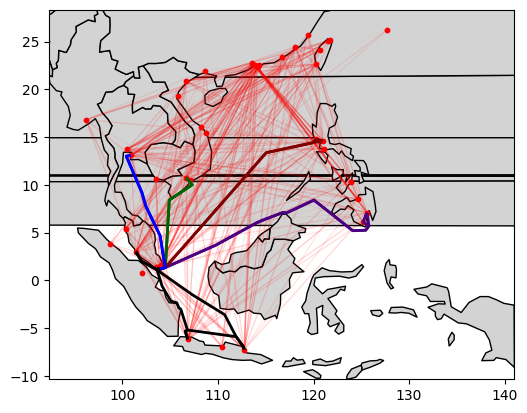
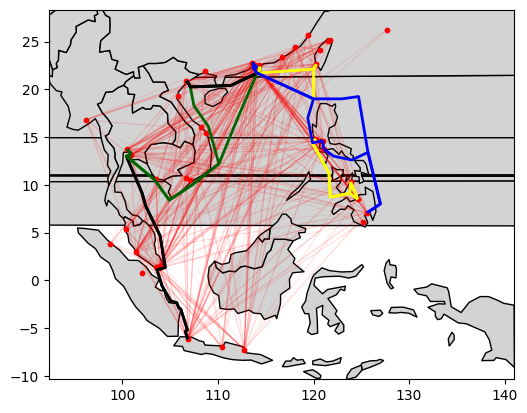

In [9]:
fig1, _ = servicegraph.plot( \
	lines_info=[
		('SPXCNC', 'indigo'), ('SGSCNC', 'darkgreen'),
		('RMNCNC', 'maroon'), ('LCXPCNC', 'blue'),
		('JSSCNC', 'black'),
	], selected_countries=southeastern_asia,
	portgraph=portgraph
)
fig2, _ = servicegraph.plot( \
	lines_info=[
		('TIXCNC', 'black'), ('RBHCNC', 'darkgreen'),
		('HHX3CNC', 'black'), ('CP3CNC', 'yellow'),
		('CP2CNC', 'blue'),
	], selected_countries=southeastern_asia,
	portgraph=portgraph
)
cma.display_two_figs(fig1, fig2)

To make it easier to distinguish, I have divided the 10 routes into two groups and plotted them in two separate images. 

The first image depicts a web-like network centered around Singapore, while the second image shows a crescent-shaped ring encircling the South China Sea.

By combining the two route maps, we obtain a complete shipping route map as shown below.

/opt/anaconda3/envs/nuscma/lib/python3.11/site-packages/shapely/predicates.py:878: RuntimeWarning: invalid value encountered in intersects
  return lib.intersects(a, b, **kwargs)


(<Figure size 640x480 with 1 Axes>, <Axes: >)

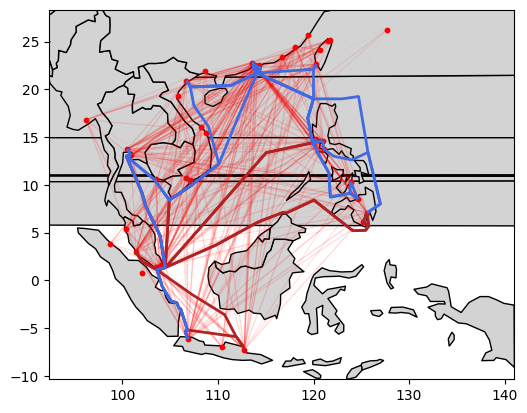

In [10]:
servicegraph.plot( \
	lines_info=[
		('SPXCNC', 'firebrick'), ('SGSCNC', 'firebrick'),
		('RMNCNC', 'firebrick'), ('LCXPCNC', 'firebrick'),
		('JSSCNC', 'firebrick'),
		('TIXCNC', 'royalblue'), ('RBHCNC', 'royalblue'),
		('HHX3CNC', 'royalblue'), ('CP3CNC', 'royalblue'),
		('CP2CNC', 'royalblue'),
	], selected_countries=southeastern_asia,
	portgraph=portgraph
)

From the above image, we can gather at least two pieces of information: 

- First, not all ports are covered by this shipping network; 

- Second, not all demands are being fulfilled.

Through a simple statistics, we found that 21 ports are not connected to the current network, which is more than half of the total. 

Among all the demand orders, 127 can be fulfilled within two transshippments, while 246 cannot be met by this requirement. These unfulfilled cargo transport demands account for around one-third of the total.

In [11]:
# statistics
isolated_ports = servicegraph.get_isolated_ports(portgraph)
print('Number of isolated ports =', len(isolated_ports))

Number of isolated ports = 21


In [12]:
# statistics
pathinfo = servicegraph.get_all_paths(portgraph)
print('Number of fulfilled demand order   =', len(pathinfo['od_pairs']))
print('Number of unfulfilled demand order =', len(pathinfo['unconnected']))
print('Sum of unfulfilled demand =', sum(pathinfo['unconnected_demand']))
print('Sum of fulfilled demand   =', sum(pathinfo['od_pairs_demand']))

Number of fulfilled demand order   = 127
Number of unfulfilled demand order = 246
Sum of unfulfilled demand = 9446.0
Sum of fulfilled demand   = 17971.0


Next, let's estimate the shipping cost of the current network.

Due to the large number of unmet demands, **for simplicity**, we will assign a penalty cost of 1000 to each unmet demand.

> **Note:**
>
> The magnitude of this panelty will significanly affect the behavior of our algorithm. 
>
> It is a tune parameter, setted in the argument of function `solve_approximated_cost` in [cma.servicegraph.py](./cma/servicegraph.py#L421). 
> If you set this parameter sufficiently large, it basically means you don't allow any demand unfulfilled. 

Furthermore, to simplify the cargo allocation problem and enable faster estimation of network costs, we pre-trained a regression model to predict the number of operational weeks for each route:

In [13]:
# create a week prediction model
week_predictor = cma.create_week_predictor()
week_predictor.summary2()

<class 'statsmodels.iolib.summary2.Summary'>
"""
                 Results: Ordinary least squares
==================================================================
Model:               OLS              Adj. R-squared:     0.890   
Dependent Variable:  weeks            AIC:                92.2984 
Date:                2025-11-22 15:51 BIC:                103.6494
No. Observations:    49               Log-Likelihood:     -40.149 
Df Model:            5                F-statistic:        78.47   
Df Residuals:        43               Prob (F-statistic): 1.71e-20
R-squared:           0.901            Scale:              0.34352 
------------------------------------------------------------------
                     Coef.  Std.Err.    t    P>|t|   [0.025 0.975]
------------------------------------------------------------------
const               -0.5243   0.3969 -1.3207 0.1936 -1.3248 0.2763
sailing_distance     0.0005   0.0000 12.8823 0.0000  0.0004 0.0006
stops_number         0.0465   0.0435  1.0711 0.2901 -0.0411 0.1342
ave_productivity     0.0004   0.0009  0.5032 0.6174 -0.0013 0.0021
ave_demand_inflows   0.0003   0.0001  1.9560 0.0570 -0.0000 0.0005
ave_demand_outflows  0.0001   0.0002  0.5695 0.5720 -0.0003 0.0005
------------------------------------------------------------------
Omnibus:               8.677        Durbin-Watson:           1.541
Prob(Omnibus):         0.013        Jarque-Bera (JB):        7.834
Skew:                  0.907        Prob(JB):                0.020
Kurtosis:              3.741        Condition No.:           31830
==================================================================
Notes:
[1] Standard Errors assume that the covariance matrix of the
errors is correctly specified.
[2] The condition number is large, 3.18e+04. This might indicate
that there are strong multicollinearity or other numerical
problems.
"""

In [14]:
# solve the optimal demand fulfillment
servicegraph.solve_approximated(portgraph, vesselpool, week_predictor)
servicegraph.total_cost()

Set parameter Username
Set parameter LicenseID to value 2724843
Academic license - for non-commercial use only - expires 2026-10-19


np.float64(11565603.65782202)

#### 2.2. MCTS Algorithm

Now, let's run the Monte Carlo Tree Search (MCTS) algorithm to optimize the current routes.

First, we create a search tree with the current routes as the root node.

In [14]:
tree = cma.MonteCarloTree(servicegraph=servicegraph,
	portgraph=portgraph, vesselpool=vesselpool,
	discount_fac=0.5,  # control the simulation deepth
	c_param=0.5,       # balance exploration and exploitation
	max_depth=20,      # how many steps of adjustments are allowed
	week_predict_model=week_predictor)

Here, we need to explain two key parameters: 

- `discount_fac`: greater than 0 and less than 1. 

  This parameter controls the simulation depth of future adjustments. The larger the discount factor, the more simulations will be taken, and the algorithm is slower. 

  In deep learning (e.g., AlphaGo), the discount factor is set to 1 because the algorithm can afford to prioritize long-term gains. 
  
  However, in our case, the discount factor needs to be less than 1, as the adjustments to the routes must be completed within a limited number of steps. This ensures that the algorithm focuses more on short-term rewards and optimization, as the route adjustments need to be made efficiently and within a constrained timeframe.

- `c_param`: greater than 0.

  This parameter balance the exploration and exploitation. The larger the value of c, the more the program favors exploration, meaning it tends to jump between different branches. Conversely, the smaller the value of c, the more the program favors exploitation, meaning it tends to delve deeper into the current branch.
  
  Users can test for different `c` and check the behavior changes of this program. It should be fun. 



Next, let's run the searching algorithm for 5 minutes:

In [15]:
import time
from IPython.display import clear_output

run_time_seconds = 5 * 60   # 5 minutes
start_time = time.time()

while True:
	if time.time() - start_time >= run_time_seconds:
		print('Run time finished')
		break
	tree.run(10, True)
	clear_output(wait=False)
	print(tree.recorder())
	print('-----------------')
	tree.display_best_node(portgraph)

{'num_expand': 160, 'num_rollout': 120}
-----------------
Best Action Trace:
Action 1:
    For the #0 line "CP2CNC -- [CNSHK, HKHKG, CNNSA, PHMNL, PHBTG, PHDVO]",
    Add Port "PHCGY" in the segment (PHBTG, PHDVO).
Siblings = 2
N visits = 105
Original cost = 11984527.287209721
Updated cost  = 12065366.1323146

Action 2:
    For the #5 line "RBHCNC -- [THBKK, THLCH, VNHPH, CNNSA, CNSHK, THLCH]",
    Add Port "VNNGH" in the segment (THLCH, THBKK).
Siblings = 4
N visits = 26
Original cost = 12065366.1323146
Updated cost  = 12114075.947191518

Action 3:
    For the #0 line "CP2CNC -- [CNSHK, HKHKG, CNNSA, PHMNL, PHBTG, PHCGY, PHDVO]",
    Add Port "VNSGN" in the segment (PHCGY, PHDVO).
Siblings = 4
N visits = 7
Original cost = 12114075.947191518
Updated cost  = 11440032.1047265

Action 4:
    For the #3 line "JSSCNC -- [SGSIN, MYPKG, IDJKT, IDSUB]",
    Add Port "CNNSA" in the segment (IDJKT, IDSUB).
Siblings = 7
N visits = 1
Original cost = 11440032.1047265
Updated cost  = 6968753.7283777

After 5 minutes of searching, the program suggests the above actions. 

> **Note:**
>
> Due to the short search time, the expansion range of the search tree is limited, so the obtained result is certainly not the best. User may try extending the search time. 
>
> Additionally, the program has a certain degree of randomness, so you may not get similar results each time you run it. Please try multiple times to obtain a more satisfactory result.

Like displayed, the program produces a sequence of actions. After each step, we can calculate the total cost after the network adjustment.

It is worth noting that the total cost does not necessarily decrease with each adjustment, indicating that our algorithm is not a greedy algorithm but rather a dynamic programming-type algorithm.

As the number of adjustments increases, some routes may become very long. This might not be ideal as these lines make the overall network more complex, even though, theoretically, the complex network imply lower costs. Users might want to choose to stop at a step where the cost reduction is most significant.

The adjustment results and relative actions can be obtained in the below way:

In [16]:
best_node_trace = tree.get_best_node_trace()
best_action_trace = best_node_trace[-1].trace_actions()

After this simple adjustment, the total cost decreases significantly by around 40%: 

In [17]:
old_cost = round(servicegraph.total_cost())
new_cost = round(best_node_trace[-1].graph.total_cost())
print(f'Original graph total cost = {old_cost}')
print(f'Updated graph total cost  = {new_cost}')

Original graph total cost = 11984527
Updated graph total cost  = 6968754


#### 2.3. Visualization of Change Steps

Finally, let's display these changes. 

In [18]:
def display_change_step(idx_line_actions, action_trace, node_trace):
	for idx_action in idx_line_actions:
		action = action_trace[idx_action]
		base_network = node_trace[idx_action].parent.graph
		print(action.explain(portgraph, base_network, idx_action + 1))
	line_name = action.get_line_name(servicegraph) # type: ignore
	updated_graph = node_trace[idx_line_actions[-1]].graph

	fig1, ax1 = servicegraph.plot(  # original line
		lines_info=[(line_name, 'blue')],
		selected_countries=southeastern_asia, portgraph=portgraph,
	)
	fig2, ax2 = updated_graph.plot(  # updated line # type: ignore
		lines_info=[(line_name, 'blue')],
		selected_countries=southeastern_asia, portgraph=portgraph,
	)
	cma.display_two_figs(fig1, fig2)

The program suggests 4 adjustments of 3 lines. 

Below are the visualizations of these actions:

Action 1:
    For the #0 line "CP2CNC -- [CNSHK, HKHKG, CNNSA, PHMNL, PHBTG, PHDVO]",
    Add Port "PHCGY" in the segment (PHBTG, PHDVO).
Action 3:
    For the #0 line "CP2CNC -- [CNSHK, HKHKG, CNNSA, PHMNL, PHBTG, PHCGY, PHDVO]",
    Add Port "VNSGN" in the segment (PHCGY, PHDVO).



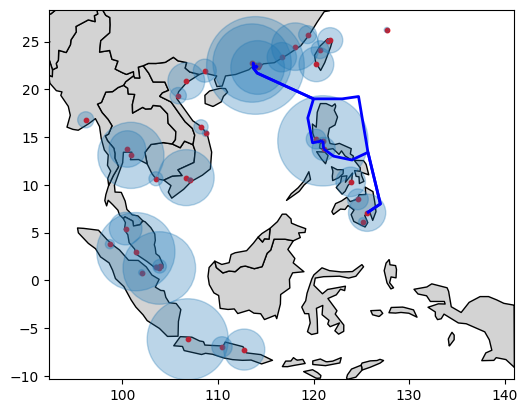
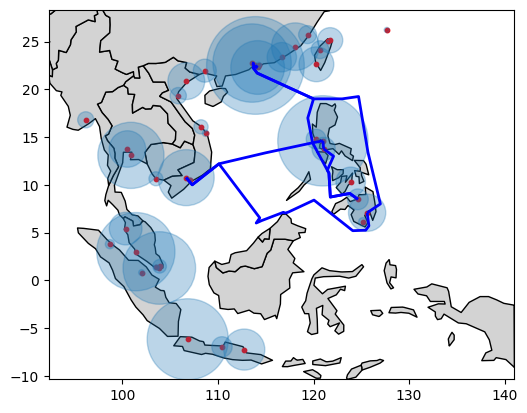

In [19]:
display_change_step([0, 2], best_action_trace, best_node_trace)

Action 2:
    For the #5 line "RBHCNC -- [THBKK, THLCH, VNHPH, CNNSA, CNSHK, THLCH]",
    Add Port "VNNGH" in the segment (THLCH, THBKK).



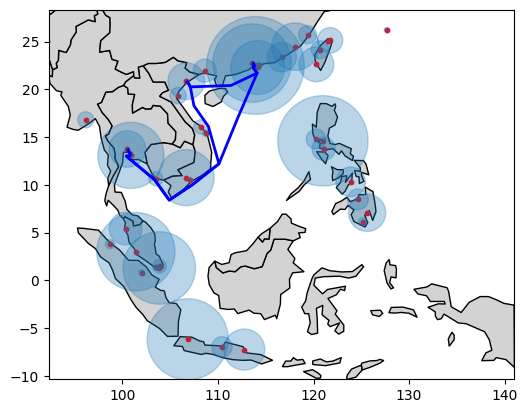
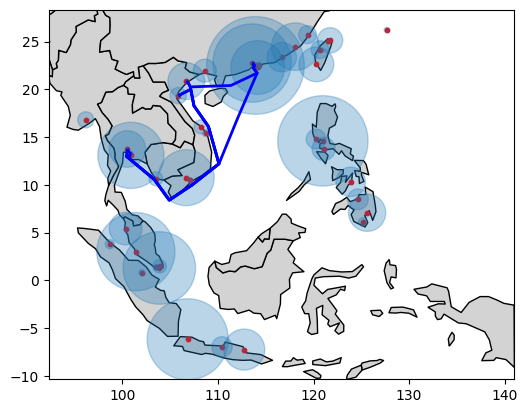

In [20]:
display_change_step([1], best_action_trace, best_node_trace)

Action 4:
    For the #3 line "JSSCNC -- [SGSIN, MYPKG, IDJKT, IDSUB]",
    Add Port "CNNSA" in the segment (IDJKT, IDSUB).



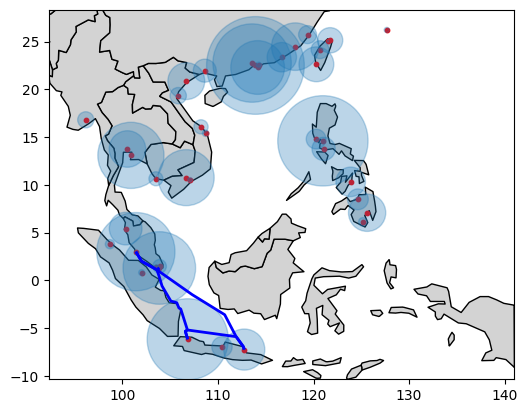
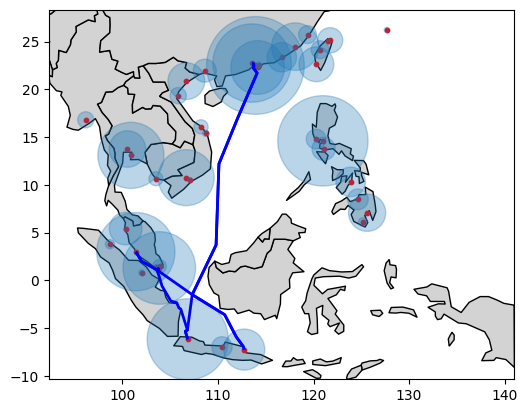

In [21]:
display_change_step([3], best_action_trace, best_node_trace)